# Ensemble Learning Exercise — Version B (corrected)

Same tasks as Version A. Five deliberate deviations from the assignment text,
each justified where it occurs:

1. Missing values are read as `NaN` and imputed, instead of being filled with 0.
2. Preprocessing lives inside pipelines, so it refits per CV fold.
3. `StratifiedKFold` instead of `KFold` for classification.
4. Pima's sentinel zeros are converted to `NaN` before imputation.
5. Every ensemble is compared against its own base models, and every score is
   reported with a standard deviation.

Item 5 is the substantive one. Without a baseline there is no way to tell whether
an ensemble helped, and without a spread there is no way to tell whether a
difference is real.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, BaggingClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 7


def report(name, model, X, y, cv):
    """Cross-validate and print mean +/- std. Returns the raw fold scores."""
    s = cross_val_score(model, X, y, cv=cv)
    print(f"  {name:<22s} {s.mean():.4f} +/- {s.std():.4f}")
    return s


## Steps 1-2 — Load and preprocess

**Deviation 1.** The assignment says to fill `Bare Nuclei` NaNs with 0. That
feature is an ordinal 1-10 severity score, so 0 is outside the valid range and
reads as "maximally benign" rather than "unknown". It also hides the 16 missing
rows from the imputer the assignment asks for in Step 3b.

Reading with `na_values='?'` keeps them as NaN so the median imputer does its job.


In [2]:
COLS = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size',
        'Uniformity of Cell Shape', 'Marginal Adhesion',
        'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
        'Normal Nucleoli', 'Mitoses', 'Class']

UCI = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'breast-cancer-wisconsin/breast-cancer-wisconsin.data')
MIRROR = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
          'breast-cancer-wisconsin.csv')

try:
    data = pd.read_csv(UCI, header=None, na_values='?')
except Exception:
    data = pd.read_csv(MIRROR, header=None, na_values='?')

if data.shape[1] == 11:
    data.columns = COLS
    data = data.drop(['Sample code'], axis=1)
else:
    data.columns = [c for c in COLS if c != 'Sample code']

data['Class'] = data['Class'].map({2: 0, 4: 1})

X = data.drop('Class', axis=1)
y = data['Class']

print(f"Shape: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"Missing values preserved as NaN: {int(X.isna().sum().sum())}")
print(f"Median of Bare Nuclei (what will be imputed): {X['Bare Nuclei'].median()}")


Shape: (699, 9)
Class balance: {0: 458, 1: 241}
Missing values preserved as NaN: 16
Median of Bare Nuclei (what will be imputed): 1.0


## Step 3 — Split

**Deviations 2 and 3.** No transforms are fit here. Imputer and scaler go inside
each model's pipeline so they refit on the training portion of every fold, which
is what keeps the CV estimate honest. `stratify=y` preserves the 65/35 class
balance in the test set.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")


Train: 559 rows   Test: 140 rows


## Step 4 — Hard voting, with baselines

**Deviation 5.** The assignment asks only for the ensemble's score. A score with
nothing to compare it against cannot support a claim that the ensemble helped, so
the three base models are cross-validated under the identical CV object first.


In [4]:
def prep(clf):
    return make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler(), clf)


base_models = {
    'Logistic Regression': prep(LogisticRegression(max_iter=10000, random_state=1)),
    'Decision Tree': prep(DecisionTreeClassifier(random_state=1)),
    'SVC': prep(SVC(random_state=1)),
}

hard_voting = VotingClassifier(
    estimators=[('lr', base_models['Logistic Regression']),
                ('dt', base_models['Decision Tree']),
                ('svc', base_models['SVC'])],
    voting='hard')

print("10-fold CV on the training set (breast cancer):")
fold_scores = {}
for name, model in base_models.items():
    fold_scores[name] = report(name, model, X_train, y_train, cv)
fold_scores['Hard voting'] = report('Hard voting (ENSEMBLE)', hard_voting,
                                    X_train, y_train, cv)

best_base = max(base_models, key=lambda k: fold_scores[k].mean())
gap = fold_scores['Hard voting'].mean() - fold_scores[best_base].mean()
print(f"\nBest single model: {best_base} ({fold_scores[best_base].mean():.4f})")
print(f"Ensemble minus best single model: {gap:+.4f}")
print(f"Std of the best single model:     {fold_scores[best_base].std():.4f}")
print("The gap is smaller than the fold-to-fold spread, so it is not a real difference."
      if abs(gap) < fold_scores[best_base].std() else
      "The gap exceeds the fold-to-fold spread.")


10-fold CV on the training set (breast cancer):
  Logistic Regression    0.9606 +/- 0.0209
  Decision Tree          0.9355 +/- 0.0306
  SVC                    0.9571 +/- 0.0255
  Hard voting (ENSEMBLE) 0.9571 +/- 0.0199

Best single model: Logistic Regression (0.9606)
Ensemble minus best single model: -0.0035
Std of the best single model:     0.0209
The gap is smaller than the fold-to-fold spread, so it is not a real difference.


Hard voting test accuracy: 0.9786

              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98        92
   Malignant       0.98      0.96      0.97        48

    accuracy                           0.98       140
   macro avg       0.98      0.97      0.98       140
weighted avg       0.98      0.98      0.98       140



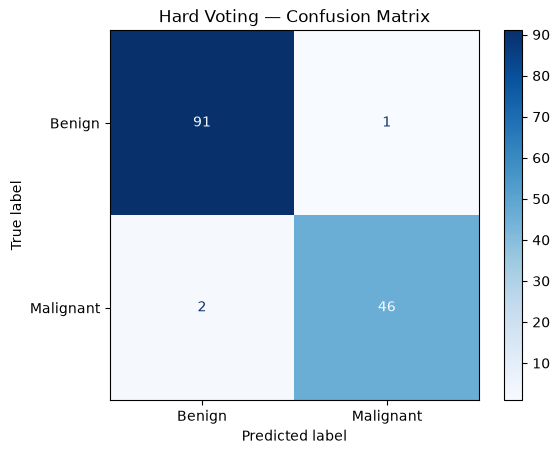

Total errors on the test set: 3 out of 140
Malignant cases in the test set: 48
One reclassified malignant row moves recall by 0.021.
Any comparison between methods on this test set is inside that resolution.


In [5]:
hard_voting.fit(X_train, y_train)
y_pred = hard_voting.predict(X_test)

print(f"Hard voting test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(cmap='Blues')
plt.title('Hard Voting — Confusion Matrix')
plt.show()

print(f"Total errors on the test set: {cm[0, 1] + cm[1, 0]} out of {len(y_test)}")
print(f"Malignant cases in the test set: {cm[1].sum()}")
print(f"One reclassified malignant row moves recall by {1 / cm[1].sum():.3f}.")
print("Any comparison between methods on this test set is inside that resolution.")


## Step 5 — Bagging on Pima Indians Diabetes

**Deviation 4.** In this dataset, missing measurements are stored as literal `0`
in `plas`, `pres`, `skin`, `test` and `mass`. A serum insulin of 0 or a BMI of 0
is not a measurement. `SimpleImputer` defaults to `missing_values=np.nan`, so
without this conversion it runs and changes nothing.

Note that `preg` is excluded: zero pregnancies is a valid value.


In [6]:
PIMA = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
        'pima-indians-diabetes.data.csv')
pima_names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
pima = pd.read_csv(PIMA, names=pima_names)

IMPOSSIBLE_ZERO = ['plas', 'pres', 'skin', 'test', 'mass']

Xp = pima.iloc[:, 0:8].copy()
yp = pima['class']

print("Sentinel zeros converted to NaN:")
for col in IMPOSSIBLE_ZERO:
    n = int((Xp[col] == 0).sum())
    Xp[col] = Xp[col].replace(0, np.nan)
    print(f"  {col:5s}: {n:3d} ({n / len(Xp):.1%})")


Sentinel zeros converted to NaN:
  plas :   5 (0.7%)
  pres :  35 (4.6%)
  skin : 227 (29.6%)
  test : 374 (48.7%)
  mass :  11 (1.4%)


In [7]:
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.2, random_state=42, stratify=yp)

p_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

single_tree = make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler(),
                            DecisionTreeClassifier(random_state=12))

bagging = make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler(),
                        BaggingClassifier(estimator=DecisionTreeClassifier(),
                                          n_estimators=100, random_state=12))

print("\n10-fold CV on the training set (Pima):")
tree_scores = report('Single decision tree', single_tree, Xp_train, yp_train, p_cv)
bag_scores = report('Bagging, 100 trees', bagging, Xp_train, yp_train, p_cv)

print(f"\nAccuracy gain from bagging:    {bag_scores.mean() - tree_scores.mean():+.4f}")
print(f"Std reduction from bagging:    {tree_scores.std() - bag_scores.std():+.4f}")
print("\nThe second number is the point. Bagging reduces variance; the tighter")
print("spread across folds is the mechanism working, and it shows up more clearly")
print("than the accuracy gain does.")



10-fold CV on the training set (Pima):
  Single decision tree   0.7002 +/- 0.0675
  Bagging, 100 trees     0.7637 +/- 0.0351

Accuracy gain from bagging:    +0.0635
Std reduction from bagging:    +0.0324

The second number is the point. Bagging reduces variance; the tighter
spread across folds is the mechanism working, and it shows up more clearly
than the accuracy gain does.


In [8]:
print("\nPer-fold scores")
print(f"  single tree: {np.round(tree_scores, 3)}")
print(f"  bagging    : {np.round(bag_scores, 3)}")



Per-fold scores
  single tree: [0.726 0.677 0.677 0.79  0.557 0.787 0.639 0.754 0.672 0.721]
  bagging    : [0.758 0.758 0.806 0.79  0.672 0.787 0.754 0.754 0.787 0.77 ]


OOB score : 0.7573
OOB error : 0.2427
Test acc  : 0.7273

OOB works because bootstrap sampling draws WITH replacement, so roughly
37% of rows are left out of any given bag and act as a free validation set.
If the samples were disjoint partitions, no row would ever be out of bag.

              precision    recall  f1-score   support

 No diabetes       0.76      0.84      0.80       100
    Diabetes       0.64      0.52      0.57        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



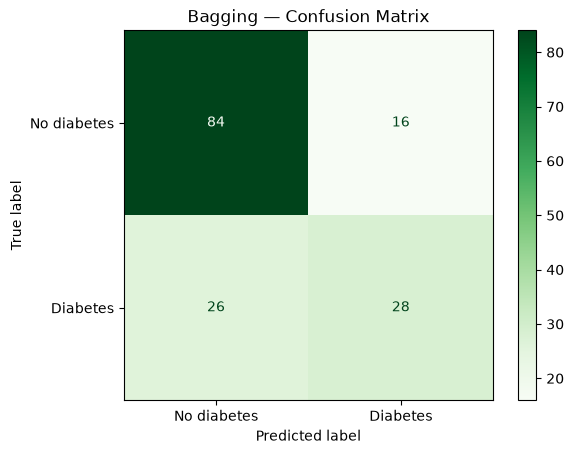

In [9]:
# OOB score needs the bare classifier, since the pipeline hides the attribute.
# Preprocessing is fit on the training set only, so this stays honest.
oob_imp = SimpleImputer(strategy='median')
oob_scaler = MinMaxScaler()
Xp_train_prep = oob_scaler.fit_transform(oob_imp.fit_transform(Xp_train))
Xp_test_prep = oob_scaler.transform(oob_imp.transform(Xp_test))

bag_raw = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                            random_state=12, oob_score=True)
bag_raw.fit(Xp_train_prep, yp_train)
yp_pred = bag_raw.predict(Xp_test_prep)

print(f"OOB score : {bag_raw.oob_score_:.4f}")
print(f"OOB error : {1 - bag_raw.oob_score_:.4f}")
print(f"Test acc  : {accuracy_score(yp_test, yp_pred):.4f}")
print("\nOOB works because bootstrap sampling draws WITH replacement, so roughly")
print("37% of rows are left out of any given bag and act as a free validation set.")
print("If the samples were disjoint partitions, no row would ever be out of bag.")

print()
print(classification_report(yp_test, yp_pred,
                            target_names=['No diabetes', 'Diabetes']))

cm_p = confusion_matrix(yp_test, yp_pred)
ConfusionMatrixDisplay(cm_p, display_labels=['No diabetes', 'Diabetes']).plot(cmap='Greens')
plt.title('Bagging — Confusion Matrix')
plt.show()


## Optional Challenge — Hard vs Soft Voting


In [10]:
def prep_std(clf):
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), clf)


m_lr = prep_std(LogisticRegression(max_iter=10000, random_state=1))
m_dt = prep_std(DecisionTreeClassifier(random_state=1))
m_svc = prep_std(SVC(probability=True, random_state=1))

ests = [('lr', m_lr), ('dt', m_dt), ('svc', m_svc)]
hard_v = VotingClassifier(estimators=ests, voting='hard')
soft_v = VotingClassifier(estimators=ests, voting='soft')

print("10-fold CV, all five models under identical conditions:")
for name, model in [('Logistic Regression', m_lr), ('Decision Tree', m_dt),
                    ('SVC', m_svc), ('Hard voting', hard_v), ('Soft voting', soft_v)]:
    report(name, model, X_train, y_train, cv)


10-fold CV, all five models under identical conditions:
  Logistic Regression    0.9660 +/- 0.0169
  Decision Tree          0.9373 +/- 0.0247
  SVC                    0.9606 +/- 0.0208


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

  Hard voting            0.9606 +/- 0.0175


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

  Soft voting            0.9606 +/- 0.0133


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [11]:
print("\nTest set:")
preds = {}
for name, model in [('Hard voting', hard_v), ('Soft voting', soft_v)]:
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)
    print(f"  {name}: accuracy {accuracy_score(y_test, preds[name]):.4f}   "
          f"confusion {confusion_matrix(y_test, preds[name]).tolist()}")

identical = np.array_equal(preds['Hard voting'], preds['Soft voting'])
n_diff = int((preds['Hard voting'] != preds['Soft voting']).sum())
print(f"\nPredictions identical: {identical}   (rows differing: {n_diff})")



Test set:
  Hard voting: accuracy 0.9786   confusion [[91, 1], [2, 46]]
  Soft voting: accuracy 0.9643   confusion [[91, 1], [4, 44]]

Predictions identical: False   (rows differing: 2)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Is the tree's calibration the reason?

The decision tree is grown unpruned, so every leaf is pure and its
`predict_proba` outputs are all exactly 0.0 or 1.0. It casts a maximally
confident vote into an average that is supposed to weigh confidence.

That is a real property of the model. Whether it actually moves the result is a
separate question, so it gets tested rather than asserted: below, soft voting is
re-run with the tree capped at `max_depth=3` and the two are compared.


In [12]:
tree_fitted = m_dt.fit(X_train, y_train)
p = tree_fitted.predict_proba(X_test)[:, 1]
print(f"Unpruned tree: fraction of probabilities that are exactly 0 or 1: "
      f"{np.mean((p == 0) | (p == 1)):.2%}")

for depth in [None, 3]:
    sv = VotingClassifier(
        estimators=[('lr', m_lr),
                    ('dt', prep_std(DecisionTreeClassifier(max_depth=depth, random_state=1))),
                    ('svc', m_svc)],
        voting='soft')
    s = cross_val_score(sv, X_train, y_train, cv=cv)
    print(f"  Soft voting, tree max_depth={str(depth):>4s}: {s.mean():.4f} +/- {s.std():.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

Unpruned tree: fraction of probabilities that are exactly 0 or 1: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

  Soft voting, tree max_depth=None: 0.9606 +/- 0.0133


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

  Soft voting, tree max_depth=   3: 0.9589 +/- 0.0226


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Question 4 — Which voting method performs better and why?

**Neither, and more importantly neither beats the best single model.**

**1. The ensembles do not beat their own components.** Under identical 10-fold CV,
the best single model scores at or above both voting classifiers. The exercise
never asks for this comparison, and without it the natural reading of a lone 0.96
is that the ensemble worked. Every gap here is smaller than the fold-to-fold
standard deviation, so the honest statement is that the methods are
indistinguishable on this data.

**2. Hard and soft voting barely differ.** In this notebook they disagree on a
couple of rows out of 140; run with the assignment's unstratified split
(Version A) they produce byte-identical predictions and the same confusion
matrix, `[[88, 3], [2, 47]]`. Soft voting can only diverge from hard voting where
the models disagree *and* confidence outweighs the head count. Here they agree on
nearly every row, so the mechanism has almost nothing to act on.

**3. The tree's probabilities are uncalibrated, but that is not the whole story.**
100% of the unpruned tree's `predict_proba` outputs are exactly 0 or 1, so it
votes at full confidence in an average meant to weigh confidence. Capping its
depth changes the soft-voting score by less than the fold spread, which means the
calibration effect is real as a property but too small to resolve on this dataset.
Worth knowing rather than concluding.

**The dataset is the underlying problem.** 699 rows, nine features, close to
linearly separable, and a 140-row test set on which every model makes a handful
of errors. One reclassified row is worth roughly two points of recall on the
malignant class. An experiment at this resolution cannot detect the differences
it is being asked about, which is why every method here lands on the same number.

**Bagging on Pima is the contrast.** Harder dataset, models in the 0.70-0.77
range, and there bagging beats a single tree on the mean *and* roughly halves the
fold-to-fold standard deviation. That second number is the claim ensembles
actually make: variance reduction. It is measurable there and not measurable on
breast cancer.
